# Predicting Trametinib Sensitivity in Cancer Cell Lines

## Introduction

This project investigates whether cancer driver mutation profiles can be used to predict the sensitivity of cancer cell lines to **Trametinib**, a small-molecule inhibitor of MEK1 and MEK2 in the RAS–RAF–MEK–ERK (MAPK) signalling pathway.

Drug-response data from the **Genomics of Drug Sensitivity in Cancer (GDSC)** are integrated with driver mutation data from **Cell Model Passports** using Sanger Model IDs.

The primary objective is to explore relationships between genomic alterations and experimentally measured Trametinib response (`LN_IC50`) and, subsequently, to develop machine learning models that predict drug sensitivity from genomic features.

### Research Question

**Can cancer driver mutation profiles predict cancer cell line sensitivity to Trametinib?**

### Initial Objectives

1. Explore and validate the GDSC drug-response data.
2. Explore the cancer driver mutation data.
3. Identify cancer cell lines with both Trametinib response and mutation data.
4. Investigate the prevalence of mutations in MAPK pathway and related cancer genes.
5. Construct a machine-learning-ready dataset linking genomic features to Trametinib response.

## Notebook Contents

This notebook focuses on the initial exploration and preparation of the project data alongside exploratory data analysis.

The analysis includes:

1. Loading the GDSC drug-response dataset.
2. Inspecting dataset dimensions, variables, and missing values.
3. Exploring the distribution of drug-response measurements.
4. Identifying Trametinib-treated cancer cell lines.
5. Loading and exploring the Cell Model Passports driver mutation dataset.
6. Assessing overlap between Trametinib-treated cell lines and available mutation data.
7. Exploring mutation prevalence in MAPK pathway and related cancer genes.
8. Preparing the data for subsequent feature engineering and machine learning analysis.

No predictive models are trained in this notebook. The purpose is to understand the available data and establish a clean foundation for the next stages of the project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import seaborn as sns

# 1. Dataset Selection

In [2]:
gdsc = pd.read_csv("../data/GDSC2-dataset.csv")
mutations = pd.read_csv("../data/mutations_summary.csv")

# Standardise gene symbols before any mutation-based analysis
mutations["gene_symbol"] = (
    mutations["gene_symbol"]
    .astype("string")
    .str.strip()
    .str.upper()
)

In [3]:
print("Dataset shape:", mutations.shape)
mutations.head()

Dataset shape: (13699, 19)


,gene_symbol,ensembl_gene_id,transcript_id,model_name,model_id,protein_mutation,rna_mutation,cdna_mutation,chromosome,position,reference,alternative,cancer_driver,cancer_predisposition_variant,effect,vaf,coding,source,gene_id
0,CASP8,ENSG00000064012,CCDS42798,GR-ST,SIDM01259,p.F338fs*11,r.1207delU,c.1011delT,chr2,201284846.0,AT,A,t,f,frameshift,0.4921,t,Sanger,SIDG03513
1,BMPR2,ENSG00000204217,CCDS33361,GR-ST,SIDM01259,p.N343fs*14,r.2172delA,c.1024delA,chr2,202530849.0,GA,G,t,f,frameshift,0.5156,t,Sanger,SIDG02364
2,MCM3AP,ENSG00000160294,CCDS13734,GR-ST,SIDM01259,p.?,r.5363+1delg,c.5038+1delg,chr21,46244805.0,AC,A,t,f,ess_splice,0.5227,t,Sanger,SIDG17421
3,DGCR8,ENSG00000128191,CCDS13773,GR-ST,SIDM01259,p.P727fs*18,r.2595_2596insa,c.2175_2176insA,chr22,20108940.0,C,CA,t,f,frameshift,0.4931,t,Sanger,SIDG06490
4,MB21D2,ENSG00000180611,CCDS3302,GR-ST,SIDM01259,p.N216fs*11,r.663delA,c.647delA,chr3,192799214.0,AT,A,t,f,frameshift,0.5747,t,Sanger,SIDG17353


The GDSC2 dataset was selected because it provides experimentally measured drug-response values across a large panel of cancer cell lines. The Cell Model Passports mutation dataset was selected because it provides driver mutation annotations linked by Sanger Model ID, enabling genomic and response data to be integrated.

# 2. Dataset Exploration

## 2.1. GDSC Drug Response Data

The GDSC dataset contains experimentally measured responses of cancer cell lines to anti-cancer compounds. Initial exploration is performed to understand the dataset structure, available variables, and data quality.

In [4]:
print("Dataset shape:", gdsc.shape)

gdsc.head()

Dataset shape: (242036, 19)


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,WEBRELEASE,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,683667,PFSK-1,SIDM01132,MB,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,684052,A673,SIDM00848,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,684057,ES5,SIDM00263,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,684059,ES7,SIDM00269,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,684062,EW-11,SIDM00203,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-3.741991,0.734047,0.128059,-0.807232


In [5]:
gdsc.info()

<class 'pandas.DataFrame'>
RangeIndex: 242036 entries, 0 to 242035
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   DATASET          242036 non-null  str    
 1   NLME_RESULT_ID   242036 non-null  int64  
 2   NLME_CURVE_ID    242036 non-null  int64  
 3   COSMIC_ID        242036 non-null  int64  
 4   CELL_LINE_NAME   242036 non-null  str    
 5   SANGER_MODEL_ID  242036 non-null  str    
 6   TCGA_DESC        240969 non-null  str    
 7   DRUG_ID          242036 non-null  int64  
 8   DRUG_NAME        242036 non-null  str    
 9   PUTATIVE_TARGET  214881 non-null  str    
 10  PATHWAY_NAME     242036 non-null  str    
 11  COMPANY_ID       242036 non-null  int64  
 12  WEBRELEASE       242036 non-null  str    
 13  MIN_CONC         242036 non-null  float64
 14  MAX_CONC         242036 non-null  float64
 15  LN_IC50          242036 non-null  float64
 16  AUC              242036 non-null  float64
 17  RM

In [6]:
gdsc.describe()

,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,DRUG_ID,COMPANY_ID,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
count,242036.0,2.420360e+05,2.420360e+05,242036.000000,242036.000000,242036.000000,242036.000000,242036.000000,242036.000000,242036.000000,2.420360e+05
mean,343.0,1.606806e+07,9.921059e+05,1594.042444,1042.966604,0.023143,23.462279,2.817079,0.882592,0.082779,7.312962e-10
std,0.0,7.028749e+04,2.209819e+05,398.740714,16.911327,0.158738,158.622810,2.762229,0.146998,0.042695,9.993925e-01
min,343.0,1.594631e+07,6.836670e+05,1003.000000,1001.000000,0.000010,0.010000,-8.747724,0.006282,0.003274,-8.254501e+00
25%,343.0,1.600719e+07,9.068050e+05,1149.000000,1043.000000,0.003002,3.000000,1.508018,0.849449,0.051107,-6.568485e-01
50%,343.0,1.606807e+07,9.097200e+05,1631.000000,1046.000000,0.010005,10.000000,3.236731,0.944196,0.076083,1.058000e-02
75%,343.0,1.612893e+07,1.240144e+06,1912.000000,1046.000000,0.010005,10.000000,4.700110,0.974934,0.106105,6.560362e-01
max,343.0,1.618978e+07,1.789883e+06,2499.000000,1101.000000,2.001054,2000.000000,13.820189,0.998904,0.299984,7.978776e+00


In [7]:
print("Unique cell lines:", gdsc["SANGER_MODEL_ID"].nunique())
print("Unique drugs:", gdsc["DRUG_NAME"].nunique())
print("Unique cancer types:", gdsc["TCGA_DESC"].nunique())

Unique cell lines: 969
Unique drugs: 286
Unique cancer types: 32


In [8]:
# Assess missing values in variables used for this analysis
columns_of_interest = [
    "SANGER_MODEL_ID",
    "CELL_LINE_NAME",
    "DRUG_NAME",
    "LN_IC50",
    "AUC",
    "Z_SCORE",
    "TCGA_DESC"
]

missing_values = gdsc[columns_of_interest].isnull().sum()

display(missing_values)

print(f"\nTotal missing values: {missing_values.sum()}")

SANGER_MODEL_ID       0
CELL_LINE_NAME        0
DRUG_NAME             0
LN_IC50               0
AUC                   0
Z_SCORE               0
TCGA_DESC          1067
dtype: int64


Total missing values: 1067


Missing values were assessed for the variables used in this study. All key identifiers (SANGER_MODEL_ID and CELL_LINE_NAME) and drug response measurements (LN_IC50, AUC, and Z_SCORE) were complete, with no missing values detected. The only missing values occurred in TCGA_DESC (1,067 records), which provides tumour type annotation. As TCGA_DESC was used only for exploratory analyses and not for constructing the matched dataset or modelling drug response, these missing values were retained and did not affect downstream preprocessing.

In [9]:
print("Duplicate rows:", gdsc.duplicated().sum())

Duplicate rows: 0


In [10]:
# Summarise drug coverage and the distribution of LN_IC50 values for each drug
# The drugs are grouped by name, putative target, and pathway, then ranked by the number of unique cell lines tested.

drug_summary = (
    gdsc.groupby(["DRUG_NAME", "PUTATIVE_TARGET", "PATHWAY_NAME"], dropna=False)
        .agg(
            n_cell_lines=("SANGER_MODEL_ID", "nunique"),
            mean_ln_ic50=("LN_IC50", "mean"),
            std_ln_ic50=("LN_IC50", "std"),
            min_ln_ic50=("LN_IC50", "min"),
            max_ln_ic50=("LN_IC50", "max")
        )
        .assign(
            range_ln_ic50=lambda x: x["max_ln_ic50"] - x["min_ln_ic50"]
        )
        .sort_values("n_cell_lines", ascending=False)
)

drug_summary.head(30)

,,,n_cell_lines,mean_ln_ic50,std_ln_ic50,min_ln_ic50,max_ln_ic50,range_ln_ic50
DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,,,,,,
MG-132,"Proteasome, CAPN1",Protein stability and degradation,969,-1.283393,0.722336,-3.171575,4.479962,7.651537
Nutlin-3a (-),MDM2,p53 pathway,968,4.416219,1.787005,-0.867722,9.340026,10.207748
Docetaxel,Microtubule stabiliser,Mitosis,968,-3.415391,2.548620,-7.308140,5.631903,12.940043
MK-2206,"AKT1, AKT2",PI3K/MTOR signaling,968,2.724173,1.486104,-2.560495,7.282918,9.843413
Palbociclib,"CDK4, CDK6",Cell cycle,968,3.440316,1.570024,-2.212706,8.871291,11.083997
Camptothecin,TOP1,DNA replication,968,-2.259385,1.836654,-5.881366,3.692250,9.573616
PD0325901,"MEK1, MEK2",ERK MAPK signaling,968,1.342255,2.143469,-7.185140,6.482915,13.668055
Staurosporine,Broad spectrum kinase inhibitor,RTK signaling,968,-2.793135,1.384601,-6.925405,3.462082,10.387487
5-Fluorouracil,Antimetabolite (DNA & RNA),Other,968,4.386510,1.715815,-0.868020,10.174480,11.042500


In [11]:
high_coverage_drugs = drug_summary[
    drug_summary["n_cell_lines"] >= 900
].sort_values("std_ln_ic50", ascending=False)

high_coverage_drugs.head(20)

,,,n_cell_lines,mean_ln_ic50,std_ln_ic50,min_ln_ic50,max_ln_ic50,range_ln_ic50
DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,,,,,,
Gemcitabine,Pyrimidine antimetabolite,DNA replication,960,-0.765812,3.009416,-6.551753,7.716931,14.268684
Docetaxel,Microtubule stabiliser,Mitosis,968,-3.415391,2.548620,-7.308140,5.631903,12.940043
BI-2536,"PLK1, PLK2, PLK3",Cell cycle,923,-1.154665,2.434221,-6.258933,5.562181,11.821114
Dasatinib,"ABL, SRC, Ephrins, PDGFR, KIT","Other, kinases",962,1.285622,2.320329,-8.642551,6.898136,15.540687
Alisertib,AURKA,Mitosis,949,1.590190,2.287407,-4.351967,6.418005,10.769972
Trametinib,"MEK1, MEK2",ERK MAPK signaling,966,0.216468,2.255970,-8.554725,6.719050,15.273775
Talazoparib,"PARP1, PARP2",Genome integrity,956,2.767533,2.211696,-4.824148,8.103714,12.927862
Pevonedistat,NAE,Other,956,0.873530,2.145611,-4.343407,8.677827,13.021234
PD0325901,"MEK1, MEK2",ERK MAPK signaling,968,1.342255,2.143469,-7.185140,6.482915,13.668055


Drug response measurements were summarised for each drug, together with its annotated putative target and pathway. For each drug, the number of unique cell lines tested was calculated alongside the mean, standard deviation, minimum, maximum, and range of LN_IC50 values.

The table was sorted by the number of tested cell lines to identify drugs with the broadest experimental coverage. Drugs with both high cell-line coverage and a wide range of LN_IC50 values are particularly suitable for downstream analysis because they provide a larger sample size and greater variation in drug response.

## 2.2. Selection and Initial Exploration of Trametinib

### Selection of Trametinib

Trametinib was selected for further analysis based on a combination of broad cell-line coverage, substantial variability in drug response, and biological interpretability.

In [12]:
# Filter the GDSC dataset to Trametinib-treated cell lines
trametinib = gdsc[gdsc["DRUG_NAME"] == "Trametinib"].copy()

print("Trametinib dataset shape:", trametinib.shape)
print("Unique Trametinib-treated cell lines:", trametinib["SANGER_MODEL_ID"].nunique())

trametinib.head()

Trametinib dataset shape: (966, 19)
Unique Trametinib-treated cell lines: 966


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,WEBRELEASE,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
76448,GDSC2,343,15946367,683667,PFSK-1,SIDM01132,MB,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,1046,Y,0.001001,1.0,2.272281,0.975755,0.116230,0.911277
76449,GDSC2,343,15946628,684052,A673,SIDM00848,UNCLASSIFIED,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,1046,Y,0.001001,1.0,1.221512,0.950128,0.149938,0.445504
76450,GDSC2,343,15946915,684057,ES5,SIDM00263,UNCLASSIFIED,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,1046,Y,0.001001,1.0,2.590889,0.982881,0.075531,1.052506
76451,GDSC2,343,15947167,684059,ES7,SIDM00269,UNCLASSIFIED,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,1046,Y,0.001001,1.0,2.889071,0.986998,0.080227,1.184680
76452,GDSC2,343,15947449,684062,EW-11,SIDM00203,UNCLASSIFIED,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,1046,Y,0.001001,1.0,3.061922,0.978852,0.098135,1.261300


In [13]:
print(
    "Duplicate Sanger Model IDs:",
    trametinib["SANGER_MODEL_ID"].duplicated().sum()
)

Duplicate Sanger Model IDs: 0


Trametinib was selected for this study because it combines broad experimental coverage (966 cancer cell lines), substantial variation in drug response, and a well-defined mechanism of action. As a MEK1/2 inhibitor targeting the MAPK signalling pathway, it provides an ideal model for investigating whether recurrent driver mutations can explain differences in drug sensitivity.

### Missing Values in the Trametinib Subset

Only 6 Trametinib-treated cell lines have missing `TCGA_DESC` values. All other variables, including the primary response variable `LN_IC50`, are complete.

The small number of missing cancer-type annotations is unlikely to substantially affect the overall analysis. These records can be retained if cancer type is not used as a model feature, or handled during preprocessing if `TCGA_DESC` is included in the final feature set.

In [14]:
# Check missing values in the Trametinib subset
trametinib.isnull().sum().sort_values(ascending=False)

TCGA_DESC          6
DATASET            0
PATHWAY_NAME       0
RMSE               0
AUC                0
LN_IC50            0
MAX_CONC           0
MIN_CONC           0
WEBRELEASE         0
COMPANY_ID         0
PUTATIVE_TARGET    0
NLME_RESULT_ID     0
DRUG_NAME          0
DRUG_ID            0
SANGER_MODEL_ID    0
CELL_LINE_NAME     0
COSMIC_ID          0
NLME_CURVE_ID      0
Z_SCORE            0
dtype: int64

In [15]:
# Summarise Trametinib response measurements
trametinib[["LN_IC50", "AUC", "Z_SCORE", "RMSE"]].describe()

,LN_IC50,AUC,Z_SCORE,RMSE
count,966.000000,966.000000,9.660000e+02,966.000000
mean,0.216468,0.829534,7.246377e-09,0.131708
std,2.255970,0.188362,1.000000e+00,0.048157
min,-8.554725,0.010009,-3.887992e+00,0.020375
25%,-0.942016,0.775142,-5.135193e-01,0.097743
50%,0.540893,0.896712,1.438080e-01,0.125228
75%,1.855009,0.963518,7.263127e-01,0.160960
max,6.719050,0.996620,2.882388e+00,0.289646


Descriptive statistics were calculated for the Trametinib response variables. LN_IC50 was selected as the primary outcome for subsequent analyses because it quantifies drug sensitivity and exhibited substantial variability across the 966 screened cancer cell lines.

## 2.3. Driver Mutation Dataset

The Cell Model Passports mutation dataset contains genomic alterations identified across cancer cell line models. This dataset will provide the genomic features used to investigate and subsequently predict Trametinib response.

Initial exploration was performed to assess the structure of the dataset, data quality, number of cancer models represented, and prevalence of mutations in genes potentially relevant to Trametinib sensitivity.

In [16]:
print("Dataset shape:", mutations.shape)

mutations.head()

Dataset shape: (13699, 19)


,gene_symbol,ensembl_gene_id,transcript_id,model_name,model_id,protein_mutation,rna_mutation,cdna_mutation,chromosome,position,reference,alternative,cancer_driver,cancer_predisposition_variant,effect,vaf,coding,source,gene_id
0,CASP8,ENSG00000064012,CCDS42798,GR-ST,SIDM01259,p.F338fs*11,r.1207delU,c.1011delT,chr2,201284846.0,AT,A,t,f,frameshift,0.4921,t,Sanger,SIDG03513
1,BMPR2,ENSG00000204217,CCDS33361,GR-ST,SIDM01259,p.N343fs*14,r.2172delA,c.1024delA,chr2,202530849.0,GA,G,t,f,frameshift,0.5156,t,Sanger,SIDG02364
2,MCM3AP,ENSG00000160294,CCDS13734,GR-ST,SIDM01259,p.?,r.5363+1delg,c.5038+1delg,chr21,46244805.0,AC,A,t,f,ess_splice,0.5227,t,Sanger,SIDG17421
3,DGCR8,ENSG00000128191,CCDS13773,GR-ST,SIDM01259,p.P727fs*18,r.2595_2596insa,c.2175_2176insA,chr22,20108940.0,C,CA,t,f,frameshift,0.4931,t,Sanger,SIDG06490
4,MB21D2,ENSG00000180611,CCDS3302,GR-ST,SIDM01259,p.N216fs*11,r.663delA,c.647delA,chr3,192799214.0,AT,A,t,f,frameshift,0.5747,t,Sanger,SIDG17353


In [17]:
mutations.info()

<class 'pandas.DataFrame'>
RangeIndex: 13699 entries, 0 to 13698
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   gene_symbol                    13699 non-null  string 
 1   ensembl_gene_id                13699 non-null  str    
 2   transcript_id                  13301 non-null  str    
 3   model_name                     13699 non-null  str    
 4   model_id                       13699 non-null  str    
 5   protein_mutation               13699 non-null  str    
 6   rna_mutation                   13699 non-null  str    
 7   cdna_mutation                  13699 non-null  str    
 8   chromosome                     13301 non-null  str    
 9   position                       13301 non-null  float64
 10  reference                      13301 non-null  str    
 11  alternative                    13301 non-null  str    
 12  cancer_driver                  13699 non-null  str    
 1

In [18]:
mutations.isnull().sum().sort_values(ascending=False)

position                         398
alternative                      398
transcript_id                    398
chromosome                       398
reference                        398
source                             0
coding                             0
vaf                                0
effect                             0
cancer_predisposition_variant      0
cancer_driver                      0
gene_symbol                        0
ensembl_gene_id                    0
cdna_mutation                      0
rna_mutation                       0
protein_mutation                   0
model_id                           0
model_name                         0
gene_id                            0
dtype: int64

In [19]:
print("Duplicate rows:", mutations.duplicated().sum())

Duplicate rows: 0


In [20]:
print("Unique models:", mutations["model_id"].nunique())
print("Unique genes:", mutations["gene_symbol"].nunique())

mutations[
    ["model_id", "model_name", "gene_symbol", "cancer_driver", 
     "cancer_predisposition_variant", "effect", "protein_mutation"]
].head(10)

Unique models: 1533
Unique genes: 613


,model_id,model_name,gene_symbol,cancer_driver,cancer_predisposition_variant,effect,protein_mutation
0,SIDM01259,GR-ST,CASP8,t,f,frameshift,p.F338fs*11
1,SIDM01259,GR-ST,BMPR2,t,f,frameshift,p.N343fs*14
2,SIDM01259,GR-ST,MCM3AP,t,f,ess_splice,p.?
3,SIDM01259,GR-ST,DGCR8,t,f,frameshift,p.P727fs*18
4,SIDM01259,GR-ST,MB21D2,t,f,frameshift,p.N216fs*11
5,SIDM01259,GR-ST,TET2,t,f,frameshift,p.L615fs*24
6,SIDM01259,GR-ST,SDHA,t,f,frameshift,p.L649fs*4
7,SIDM01259,GR-ST,DAXX,t,f,frameshift,p.R306fs*38
8,SIDM01259,GR-ST,IKZF1,t,f,frameshift,p.R105fs*4
9,SIDM01259,GR-ST,KMT2C,t,f,frameshift,p.A3825fs*21


Each row represents a mutation record associated with a particular cancer cell line. A cell line can appear multiple times because it may contain mutations in multiple genes, or more than one mutation record within the same gene. Individual cell lines can therefore appear multiple times, reflecting mutations in different genes. The model_id field provides the identifier used to link genomic data to the GDSC drug-response dataset, while gene_symbol identifies the affected gene. For machine learning, these data will subsequently need to be transformed from long format into a feature matrix containing one row per cell line and genomic features as columns.

# 3. Data Preprocessing

## 3.1. Identify Overlapping Cell Lines

### Overlap Between Trametinib Response and Mutation Data

In [21]:
# Identify Trametinib-treated cell lines
trametinib_models = set(trametinib["SANGER_MODEL_ID"])

# Identify cell lines represented in the mutation dataset
mutation_models = set(mutations["model_id"])

# Find models present in both datasets
overlapping_models = trametinib_models.intersection(mutation_models)

print("Trametinib-treated cell lines:", len(trametinib_models))
print("Cell lines with mutation data:", len(mutation_models))
print("Overlapping cell lines:", len(overlapping_models))
print(
    "Percentage of Trametinib-treated cell lines with mutation data:",
    round(len(overlapping_models) / len(trametinib_models) * 100, 1),
    "%"
)

Trametinib-treated cell lines: 966
Cell lines with mutation data: 1533
Overlapping cell lines: 948
Percentage of Trametinib-treated cell lines with mutation data: 98.1 %


Of the 966 cancer cell lines with Trametinib response measurements, 948 (98.1%) are also represented in the driver mutation dataset. This high level of overlap indicates that genomic features can be linked to drug-response measurements for almost the entire Trametinib cohort, providing a strong foundation for subsequent feature engineering and machine learning analysis. The remaining 18 cell lines without matched mutation data will be excluded from analyses requiring genomic features.

## 3.2. Create the matched mutation cohort

In [22]:
# Filter mutation data to cell lines with Trametinib response data
# Retain mutation records only for cell lines with available Trametinib response data
trametinib_mutations = mutations[
    mutations["model_id"].isin(overlapping_models)
].copy()

print("Mutation records in matched cohort:", trametinib_mutations.shape[0])
print("Unique matched cell lines:", trametinib_mutations["model_id"].nunique())
print("Unique mutated genes:", trametinib_mutations["gene_symbol"].nunique())

Mutation records in matched cohort: 8522
Unique matched cell lines: 948
Unique mutated genes: 597


In [23]:
duplicate_model_gene_pairs = (
    trametinib_mutations
    .duplicated(subset=["model_id", "gene_symbol"])
    .sum()
)

print("Duplicate model-gene pairs:", duplicate_model_gene_pairs)

Duplicate model-gene pairs: 687


There were 687 duplicated cell-line/gene combinations because some cell lines contained multiple recorded variants within the same gene. These records were retained in the long-format dataset, but each gene was counted only once per cell line in gene-prevalence and mutation-burden analyses.

## 3.3. Create the Matched Trametinib Response Cohort

In [24]:
trametinib_matched = trametinib[
    trametinib["SANGER_MODEL_ID"].isin(overlapping_models)
].copy()

print(
    "Matched Trametinib response rows:",
    trametinib_matched.shape[0]
)
print(
    "Matched Trametinib cell lines:",
    trametinib_matched["SANGER_MODEL_ID"].nunique()
)

Matched Trametinib response rows: 948
Matched Trametinib cell lines: 948


## 3.4. Merge drug response and mutation data

### Merging Drug Response and Mutation Data

Drug response measurements and driver mutation data were merged using the shared Sanger Model ID. The resulting dataset links experimentally measured Trametinib response with the genomic profile of each cancer cell line. Initially, the merged dataset remains in long format, with each row representing a single mutation associated with a specific cell line.

In [25]:
conn = sqlite3.connect("trametinib.db")

trametinib_matched.to_sql(
    "trametinib_matched",
    conn,
    if_exists="replace",
    index=False
)

trametinib_mutations.to_sql(
    "trametinib_mutations",
    conn,
    if_exists="replace",
    index=False
)

query = """
SELECT
    t.SANGER_MODEL_ID,
    t.CELL_LINE_NAME,
    t.TCGA_DESC,
    t.LN_IC50,
    t.AUC,
    t.Z_SCORE,
    m.gene_symbol,
    m.effect,
    m.protein_mutation,
    m.cdna_mutation,
    m.chromosome,
    m.position,
    m.reference,
    m.alternative,
    m.cancer_driver
FROM trametinib_matched AS t
INNER JOIN trametinib_mutations AS m
    ON t.SANGER_MODEL_ID = m.model_id
"""

merged = pd.read_sql_query(query, conn)

# Close the SQLite connection
conn.close()

## 3.5. Validate the merged dataset

In [26]:
print("Merged dataset shape:", merged.shape)
print("Unique matched cell lines:", merged["SANGER_MODEL_ID"].nunique())
print("Unique mutated genes:", merged["gene_symbol"].nunique())
print("Missing gene symbols:", merged["gene_symbol"].isna().sum())
print("Duplicate merged rows:", merged.duplicated().sum())

Merged dataset shape: (8522, 15)
Unique matched cell lines: 948
Unique mutated genes: 597
Missing gene symbols: 0
Duplicate merged rows: 0


The final merged dataset contained 8,522 mutation records across 948 Trametinib-treated cancer cell lines and 597 unique driver genes. No mutation records had missing gene symbols, and no fully duplicated rows were detected. Genomic-level mutation fields were retained because some distinct DNA variants produced the same protein-level consequence and would otherwise appear duplicated after merging.

# 4. Exploratory Data Analysis

In [27]:
total_driver_mutation_counts = (
    merged.groupby("SANGER_MODEL_ID")["gene_symbol"]
    .count()
    .sort_values(ascending=False)
)

total_driver_mutation_counts.head()

SANGER_MODEL_ID
SIDM00217    147
SIDM00282    139
SIDM01045    106
SIDM00193    103
SIDM00333     80
Name: gene_symbol, dtype: int64

## 4.1. Distribution of Trametinib Response

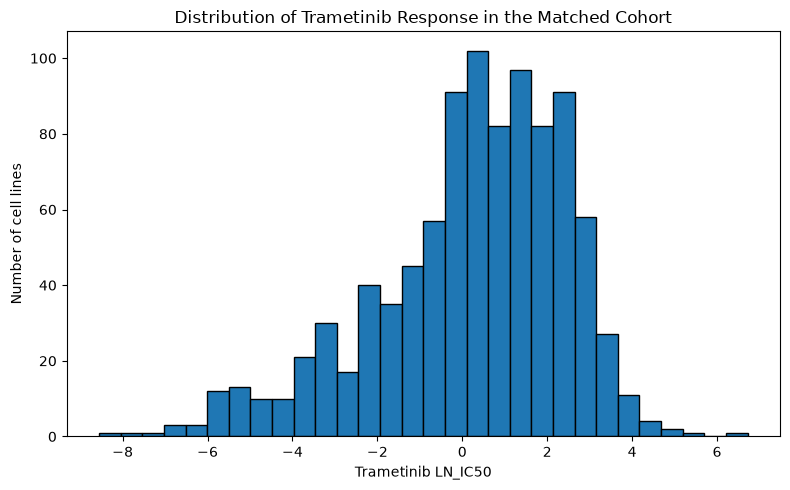

In [28]:
plt.figure(figsize=(8, 5))

plt.hist(
    trametinib_matched["LN_IC50"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Trametinib LN_IC50")
plt.ylabel("Number of cell lines")
plt.title("Distribution of Trametinib Response in the Matched Cohort")

plt.tight_layout()
plt.show()

Trametinib LN_IC50 values showed substantial variation across the 948
matched cancer cell lines, indicating considerable heterogeneity in drug
response. This variation supports the use of LN_IC50 as a continuous
target for subsequent regression modelling. Lower LN_IC50 values
indicate greater sensitivity to Trametinib.

## 4.2. Outlier Identification

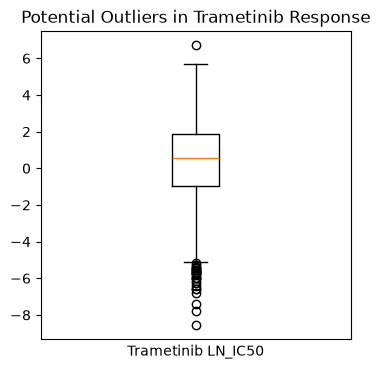

In [29]:
plt.figure(figsize=(4, 4))

plt.boxplot(trametinib["LN_IC50"], orientation="vertical")

plt.xlabel("Trametinib LN_IC50")
plt.xticks([])          # Removes the "1"
plt.title("Potential Outliers in Trametinib Response")

plt.show()

The boxplot identified several observations beyond the conventional
interquartile-range whiskers at both extremes of the LN_IC50
distribution. These observations were retained because they may
represent genuine biological variation in Trametinib sensitivity rather
than measurement or data-entry errors. Removing them could exclude
highly sensitive or resistant cell lines that are relevant to the
research question.

## 4.3. Cancer-Type Composition of the Matched Cohort

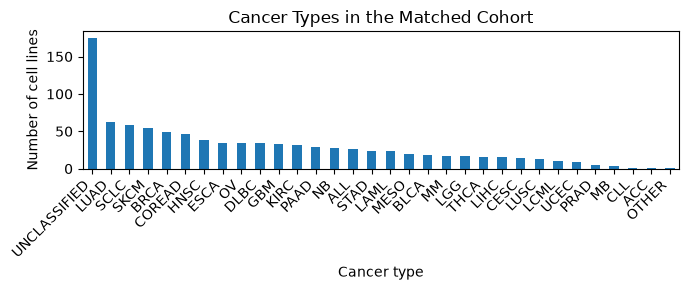

In [30]:
cancer_counts = (
    trametinib_matched["TCGA_DESC"]
    .value_counts()
)

plt.figure(figsize=(7,3))
cancer_counts.plot(kind="bar")

plt.xlabel("Cancer type")
plt.ylabel("Number of cell lines")
plt.title("Cancer Types in the Matched Cohort")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The matched cohort represents a wide range of tumour types. While a substantial proportion of cell lines are classified as UNCLASSIFIED, the remaining cell lines span numerous cancer types, including lung adenocarcinoma (LUAD), small cell lung cancer (SCLC), skin cutaneous melanoma (SKCM), breast cancer (BRCA) and colorectal adenocarcinoma (COREAD). This diversity provides a broad biological context for investigating genomic predictors of Trametinib response.

## 4.4 Overall Driver Mutation Burden

In [31]:
# Count unique mutated driver genes per cell line

total_driver_gene_counts = (
    merged.groupby("SANGER_MODEL_ID")["gene_symbol"]
    .nunique()
    .sort_values(ascending=False)
)

total_driver_gene_counts.head()

SANGER_MODEL_ID
SIDM00217    114
SIDM00282    108
SIDM01045     91
SIDM00193     77
SIDM01016     68
Name: gene_symbol, dtype: int64

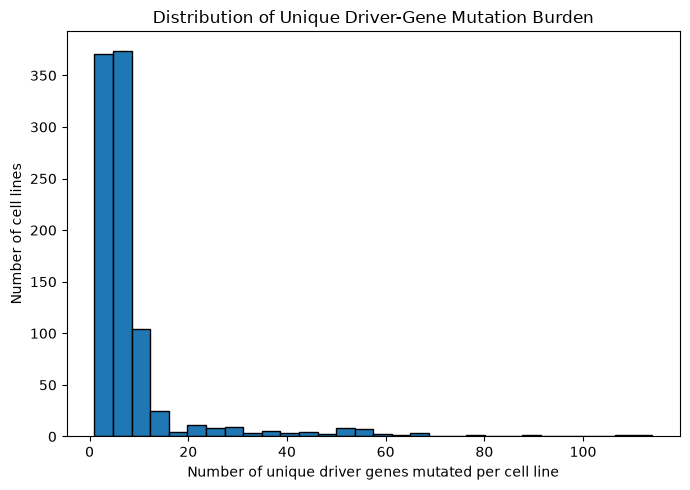

In [32]:
plt.figure(figsize=(7, 5))

plt.hist(
    total_driver_gene_counts,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Number of unique driver genes mutated per cell line")
plt.ylabel("Number of cell lines")
plt.title("Distribution of Unique Driver-Gene Mutation Burden")

plt.tight_layout()
plt.show()

In [33]:
display(total_driver_gene_counts.describe())

count    948.000000
mean       8.264768
std       11.337789
min        1.000000
25%        4.000000
50%        5.000000
75%        8.000000
max      114.000000
Name: gene_symbol, dtype: float64

The number of unique mutated driver genes varied substantially across
the matched cell lines. Most models contained relatively few altered
driver genes, while a smaller number showed considerably higher
driver-gene mutation burdens.

## 4.5. Driver Mutation Prevalence

The 948 cancer cell lines with both Trametinib response and driver mutation data contained 8,522 mutation records across 597 genes. TP53 was the most frequently mutated gene, with mutations present in 643 cell lines. Several genes with direct relevance to MAPK signalling were also among the most frequently mutated, including KRAS (125 cell lines) and BRAF (82 cell lines). This supports further investigation of MAPK pathway alterations as potential genomic features associated with Trametinib response.

In [34]:
# Count the number of cell lines with a mutation in each gene
mutation_prevalence = (
    trametinib_mutations
    .groupby("gene_symbol")["model_id"]
    .nunique()
    .sort_values(ascending=False)
)

mutation_prevalence.head(20)

gene_symbol
TP53       643
KRAS       125
KMT2C      124
PTEN       106
KMT2D      104
RB1         97
PIK3CA      93
EP300       87
HLA-A       84
ARID1A      84
BRAF        82
SDHA        78
CDKN2A      76
LRP1B       71
POLQ        69
CREBBP      66
HLA-B       64
SMARCA4     63
CBLC        63
FAT3        63
Name: model_id, dtype: int64

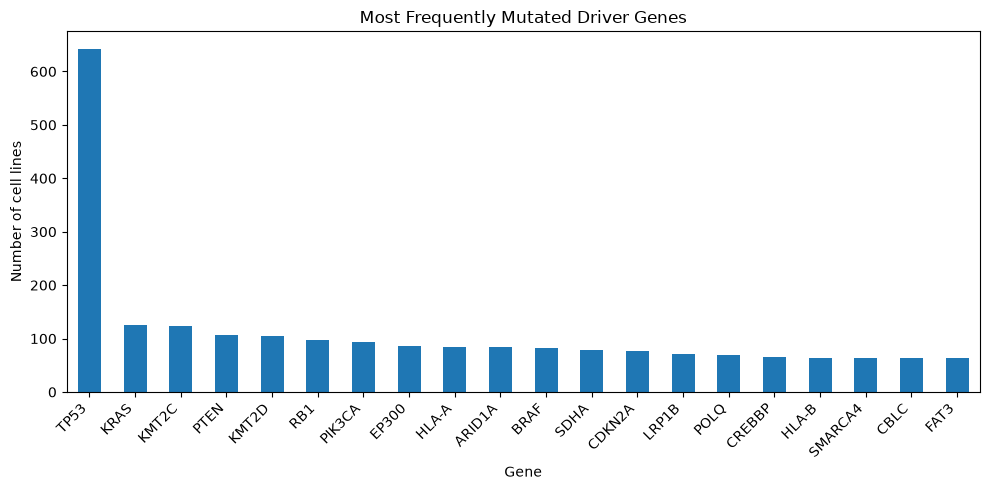

In [35]:
plt.figure(figsize=(10,5))

mutation_prevalence.head(20).plot(kind="bar")

plt.ylabel("Number of cell lines")
plt.xlabel("Gene")
plt.title("Most Frequently Mutated Driver Genes")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

TP53 was the most frequently mutated gene in the matched cohort, followed by KRAS, BRAF, PTEN and PIK3CA. Many of the most common alterations occur in well-established cancer driver genes involved in cell-cycle regulation and signalling pathways. Notably, several genes within the MAPK pathway, including KRAS, BRAF and NRAS, were well represented, supporting further investigation of their relationship with Trametinib sensitivity.

## 4.6. MAPK Pathway Alterations

Because Trametinib inhibits MEK1/2 within the RAS–RAF–MEK–ERK
signalling pathway, MAPK pathway alterations are of particular
mechanistic interest. A defined MAPK-related gene set was used to
identify pathway mutations in the matched cohort.

In [36]:
# MAPK-pathway genes used for this analysis

mapk_pathway_gene_set = {
    # RAS family and regulators
    "KRAS", "NRAS", "HRAS",
    "NF1", "RASA1", "RASA2", "RASA3", "RASA4",

    # RAF proteins
    "BRAF", "RAF1", "ARAF",

    # MEK proteins
    "MAP2K1", "MAP2K2",

    # ERK proteins
    "MAPK1", "MAPK3",

    # Receptor tyrosine kinases
    "EGFR", "ERBB2", "ERBB3", "ERBB4",
    "FGFR1", "FGFR2", "FGFR3", "FGFR4",
    "MET", "KIT", "PDGFRA", "PDGFRB",
    "ALK", "RET", "ROS1",

    # Upstream signalling proteins
    "SOS1", "SOS2", "GRB2", "SHC1",

    # MAPK phosphatases and feedback regulators
    "DUSP4", "DUSP5", "DUSP6",
    "SPRY1", "SPRY2", "SPRY4",

    # Other MAPK pathway members
    "MAP3K1", "MAP3K2", "MAP3K3", "MAP3K4",
    "MAP3K5", "MAP3K7", "MAP3K8",
    "MAP2K3", "MAP2K4", "MAP2K5", "MAP2K6", "MAP2K7",
    "MAPK7", "MAPK8", "MAPK9", "MAPK10",
    "MAPK11", "MAPK12", "MAPK13", "MAPK14"
}

print("Number of genes in MAPK gene set:", len(mapk_pathway_gene_set))

Number of genes in MAPK gene set: 60


In [37]:
# Prepare the MAPK analysis data
# Keep only the columns required for this analysis

mapk_data = merged[
    ["SANGER_MODEL_ID", "gene_symbol", "LN_IC50"]
].copy()

display(mapk_data.head())
print("Initial shape:", mapk_data.shape)

,SANGER_MODEL_ID,gene_symbol,LN_IC50
0,SIDM01132,GMPS,2.272281
1,SIDM01132,TP53,2.272281
2,SIDM00848,BRAF,1.221512
3,SIDM00848,TP53,1.221512
4,SIDM00263,FBN2,2.590889


Initial shape: (8522, 3)


In [38]:
# Convert LN_IC50 to a numeric column

mapk_data["LN_IC50"] = pd.to_numeric(
    mapk_data["LN_IC50"],
    errors="coerce"
)

# Remove rows missing information needed for the analysis

mapk_data = mapk_data.dropna(
    subset=["SANGER_MODEL_ID", "gene_symbol", "LN_IC50"]
)

print("Shape after removing missing values:", mapk_data.shape)
print("\nMissing values remaining:")
print(
    mapk_data[
        ["SANGER_MODEL_ID", "gene_symbol", "LN_IC50"]
    ].isna().sum()
)

Shape after removing missing values: (8522, 3)

Missing values remaining:
SANGER_MODEL_ID    0
gene_symbol        0
LN_IC50            0
dtype: int64


In [39]:
# A gene may appear more than once for the same cell line.
# For mutation burden, each mutated gene should count only once per cell line.

rows_before = len(mapk_data)

mapk_data = mapk_data.drop_duplicates(
    subset=["SANGER_MODEL_ID", "gene_symbol"]
)

rows_after = len(mapk_data)

print("Rows before removing duplicates:", rows_before)
print("Rows after removing duplicates:", rows_after)
print("Duplicate rows removed:", rows_before - rows_after)

Rows before removing duplicates: 8522
Rows after removing duplicates: 7835
Duplicate rows removed: 687


In [40]:
# True means the mutated gene belongs to the defined MAPK gene set

mapk_data["is_MAPK_mutation"] = (
    mapk_data["gene_symbol"].isin(mapk_pathway_gene_set)
)

display(mapk_data.head())

,SANGER_MODEL_ID,gene_symbol,LN_IC50,is_MAPK_mutation
0,SIDM01132,GMPS,2.272281,False
1,SIDM01132,TP53,2.272281,False
2,SIDM00848,BRAF,1.221512,True
3,SIDM00848,TP53,1.221512,False
4,SIDM00263,FBN2,2.590889,False


In [41]:
print(mapk_data["is_MAPK_mutation"].value_counts())

is_MAPK_mutation
False    7285
True      550
Name: count, dtype: int64


In [42]:
# Count the number of unique cell lines mutated in each MAPK-related gene

mapk_gene_frequencies = (
    mapk_data.loc[
        mapk_data["is_MAPK_mutation"]
    ]
    .groupby("gene_symbol")["SANGER_MODEL_ID"]
    .nunique()
    .sort_values(ascending=False)
)

display(mapk_gene_frequencies)

gene_symbol
KRAS      125
BRAF       82
NRAS       59
NF1        56
EGFR       21
RASA1      17
ERBB2      16
MAP2K4     15
ERBB4      14
MAP2K1     14
MAP2K7     12
ALK        12
RASA2      12
MET        11
FGFR4      10
ERBB3      10
FGFR2       8
MAP3K1      8
HRAS        8
RET         7
SOS1        7
FGFR3       7
KIT         6
PDGFRA      5
RAF1        4
FGFR1       2
PDGFRB      1
MAP2K2      1
Name: SANGER_MODEL_ID, dtype: int64

In [43]:
key_mapk_driver_genes = [
    "KRAS",
    "BRAF",
    "NRAS",
    "NF1",
    "MAP2K1",
    "HRAS",
    "RAF1",
    "MAP2K2"
]

In [44]:
key_mapk_driver_prevalence = (
    mutation_prevalence
    .reindex(key_mapk_driver_genes)
    .fillna(0)
    .astype(int)
    .sort_values(ascending=False)
)

display(key_mapk_driver_prevalence)

gene_symbol
KRAS      125
BRAF       82
NRAS       59
NF1        56
MAP2K1     14
HRAS        8
RAF1        4
MAP2K2      1
Name: model_id, dtype: int64

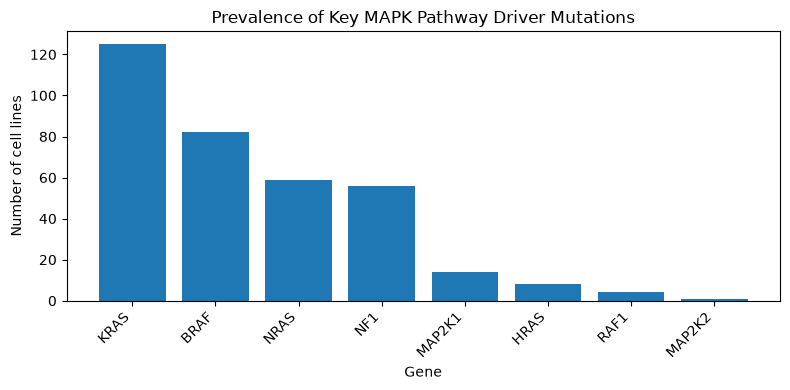

In [45]:
plt.figure(figsize=(8, 4))

plt.bar(
    key_mapk_driver_prevalence.index,
    key_mapk_driver_prevalence.values
)

plt.xlabel("Gene")
plt.ylabel("Number of cell lines")
plt.title("Prevalence of Key MAPK Pathway Driver Mutations")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

KRAS was the most frequently mutated MAPK-related driver gene, followed
by BRAF, NRAS and NF1. These recurrent alterations were sufficiently
represented within the matched cohort to support subsequent analyses of
their association with Trametinib sensitivity.

## 4.7 MAPK Mutation Burden and Trametinib Response

To investigate pathway-level associations, the number of unique mutated
MAPK pathway genes was calculated for each cell line. Duplicate
cell-line/gene combinations were removed so that each mutated gene
contributed a maximum of one count per cell line.

In [46]:
# Count the number of unique mutated MAPK genes in each cell line

mapk_mutation_counts = (
    mapk_data
    .groupby("SANGER_MODEL_ID")["is_MAPK_mutation"]
    .sum()
    .rename("MAPK_mutation_count")
)

display(mapk_mutation_counts.head())

SANGER_MODEL_ID
SIDM00003    2
SIDM00023    0
SIDM00040    0
SIDM00042    1
SIDM00043    0
Name: MAPK_mutation_count, dtype: int64

In [47]:
# Obtain one Trametinib response value per cell line

cell_line_ic50 = (
    mapk_data
    .groupby("SANGER_MODEL_ID")["LN_IC50"]
    .median()
    .rename("LN_IC50")
)

display(cell_line_ic50.head())

SANGER_MODEL_ID
SIDM00003   -6.416117
SIDM00023    0.550402
SIDM00040   -0.228455
SIDM00042   -1.140312
SIDM00043   -0.671703
Name: LN_IC50, dtype: float64

In [48]:
# Create the final analysis table by combining the two tables:
# one row per unique cell-line model

cell_line_mapk = pd.concat(
    [mapk_mutation_counts, cell_line_ic50],
    axis=1
).reset_index()

display(cell_line_mapk.head())

print(
    "Number of unique cell lines:",
    cell_line_mapk["SANGER_MODEL_ID"].nunique()
)

print("Shape of analysis table:", cell_line_mapk.shape)

,SANGER_MODEL_ID,MAPK_mutation_count,LN_IC50
0,SIDM00003,2,-6.416117
1,SIDM00023,0,0.550402
2,SIDM00040,0,-0.228455
3,SIDM00042,1,-1.140312
4,SIDM00043,0,-0.671703


Number of unique cell lines: 948
Shape of analysis table: (948, 3)


In [49]:
# Validate the table - confirm that there is exactly one row per cell line

print(
    "Duplicate cell-line IDs:",
    cell_line_mapk["SANGER_MODEL_ID"].duplicated().sum()
)

print("\nMissing values:")
print(cell_line_mapk.isna().sum())

print("\nMAPK mutation count summary:")
display(cell_line_mapk["MAPK_mutation_count"].describe())

Duplicate cell-line IDs: 0

Missing values:
SANGER_MODEL_ID        0
MAPK_mutation_count    0
LN_IC50                0
dtype: int64

MAPK mutation count summary:


count    948.000000
mean       0.580169
std        0.803180
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        6.000000
Name: MAPK_mutation_count, dtype: float64

In [50]:
# Number of cell lines in each MAPK mutation-count group

mapk_count_distribution = (
    cell_line_mapk["MAPK_mutation_count"]
    .value_counts()
    .sort_index()
)

print(mapk_count_distribution)

MAPK_mutation_count
0    527
1    330
2     69
3     12
4      5
5      4
6      1
Name: count, dtype: int64


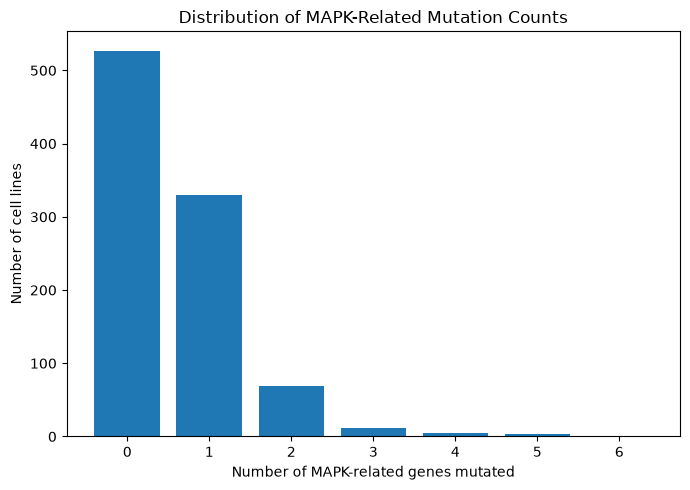

In [51]:
plt.figure(figsize=(7, 5))

plt.bar(
    mapk_count_distribution.index.astype(str),
    mapk_count_distribution.values
)

plt.xlabel("Number of MAPK-related genes mutated")
plt.ylabel("Number of cell lines")
plt.title("Distribution of MAPK-Related Mutation Counts")

plt.tight_layout()
plt.show()

In [52]:
mapk_group_sizes = (
    cell_line_mapk["MAPK_mutation_count"]
    .value_counts()
    .sort_index()
)

mapk_order = mapk_group_sizes.index.tolist()

mapk_tick_labels = [
    f"{count}\n(n={mapk_group_sizes.loc[count]})"
    for count in mapk_order
]

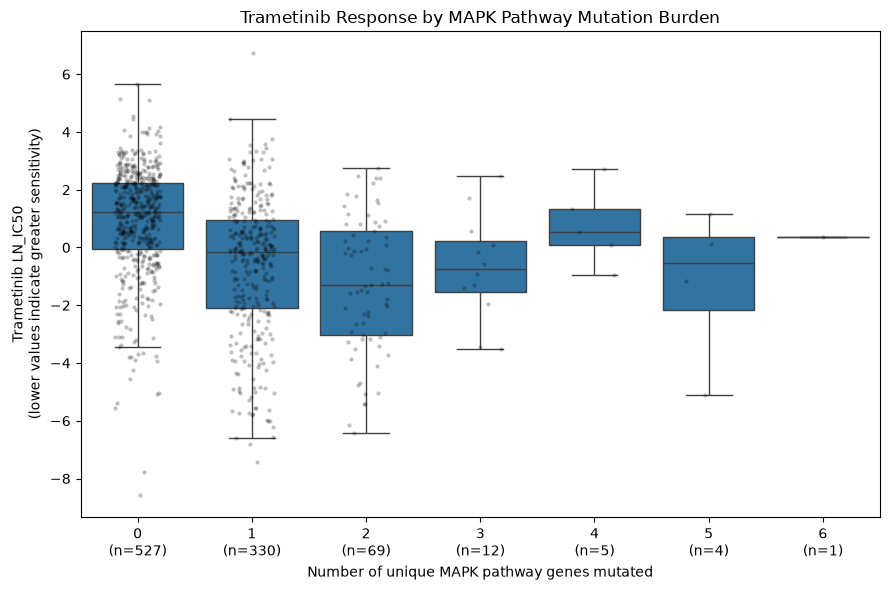

In [53]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=cell_line_mapk,
    x="MAPK_mutation_count",
    y="LN_IC50",
    order=mapk_order,
    showfliers=False
)

sns.stripplot(
    data=cell_line_mapk,
    x="MAPK_mutation_count",
    y="LN_IC50",
    order=mapk_order,
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.2
)

plt.xticks(
    ticks=range(len(mapk_order)),
    labels=mapk_tick_labels
)

plt.xlabel("Number of unique MAPK pathway genes mutated")
plt.ylabel(
    "Trametinib LN_IC50\n"
    "(lower values indicate greater sensitivity)"
)

plt.title(
    "Trametinib Response by MAPK Pathway Mutation Burden"
)

plt.tight_layout()
plt.show()

In [54]:
from scipy.stats import pearsonr, spearmanr
# Pearson: tests for a linear relationship
pearson_r, pearson_p = pearsonr(
    cell_line_mapk["MAPK_mutation_count"],
    cell_line_mapk["LN_IC50"]
)

# Spearman: tests whether the variables generally increase/decrease together
# without requiring a linear relationship
spearman_r, spearman_p = spearmanr(
    cell_line_mapk["MAPK_mutation_count"],
    cell_line_mapk["LN_IC50"]
)


print("Pearson correlation")
print(f"r = {pearson_r:.3f}")
print(f"p = {pearson_p:.4g}")

print("\nSpearman correlation")
print(f"rho = {spearman_r:.3f}")
print(f"p = {spearman_p:.4g}")

Pearson correlation
r = -0.306
p = 5.332e-22

Spearman correlation
rho = -0.375
p = 5.461e-33


A statistically significant negative association was observed between
MAPK pathway mutation burden and Trametinib LN_IC50
(Pearson r = −0.306, p = 5.332 × 10⁻²²; Spearman ρ = −0.375,
p = 5.461 × 10⁻³³). This indicates that cell lines with a greater number
of mutated MAPK pathway genes tended to exhibit lower LN_IC50 values and
therefore greater Trametinib sensitivity.

The Spearman correlation was slightly stronger than the Pearson
correlation, suggesting that the association was monotonic but not
strictly linear. Considerable variation remained within each group, and
the groups containing four or more mutated MAPK genes included very few
cell lines and should therefore be interpreted cautiously.

## 4.8. KRAS Mutation Status and Trametinib Response

Following the pathway-level analysis, recurrent individual driver genes
were examined to determine whether specific MAPK pathway alterations
were associated with Trametinib sensitivity. KRAS was selected because
it was the most frequently mutated MAPK-related driver gene in the
matched cohort.

In [55]:
# Identify cell lines with a KRAS mutation
kras_models = set(
    trametinib_mutations.loc[
        trametinib_mutations["gene_symbol"] == "KRAS",
        "model_id"
    ]
)

In [56]:
trametinib_matched["KRAS_status"] = np.where(
    trametinib_matched["SANGER_MODEL_ID"].isin(kras_models),
    "Mutant",
    "Wild type"
)
print(trametinib_matched)

      DATASET  NLME_RESULT_ID  NLME_CURVE_ID  COSMIC_ID CELL_LINE_NAME  \
76448   GDSC2             343       15946367     683667         PFSK-1   
76449   GDSC2             343       15946628     684052           A673   
76450   GDSC2             343       15946915     684057            ES5   
76451   GDSC2             343       15947167     684059            ES7   
76452   GDSC2             343       15947449     684062          EW-11   
...       ...             ...            ...        ...            ...   
77409   GDSC2             343       16188502    1660034        SNU-407   
77410   GDSC2             343       16188773    1660035         SNU-61   
77411   GDSC2             343       16189040    1660036         SNU-81   
77412   GDSC2             343       16189291    1674021         SNU-C5   
77413   GDSC2             343       16189573    1789883           DiFi   

      SANGER_MODEL_ID     TCGA_DESC  DRUG_ID   DRUG_NAME PUTATIVE_TARGET  \
76448       SIDM01132            MB

In [57]:
kras_summary = (
    trametinib_matched
    .groupby("KRAS_status")["LN_IC50"]
    .agg(
        n="count",
        median="median",
        mean="mean",
        standard_deviation="std"
    )
)

display(kras_summary)

,n,median,mean,standard_deviation
KRAS_status,,,,
Mutant,125,-0.763416,-0.924487,2.130917
Wild type,823,0.699956,0.370197,2.241659


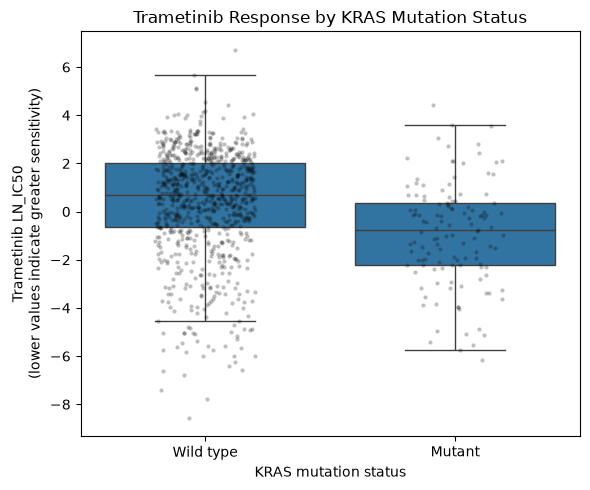

In [58]:
plt.figure(figsize=(6, 5))

sns.boxplot(
    data=trametinib_matched,
    x="KRAS_status",
    y="LN_IC50",
    order=["Wild type", "Mutant"],
    showfliers=False
)

sns.stripplot(
    data=trametinib_matched,
    x="KRAS_status",
    y="LN_IC50",
    order=["Wild type", "Mutant"],
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.2
)

plt.xlabel("KRAS mutation status")
plt.ylabel(
    "Trametinib LN_IC50\n"
    "(lower values indicate greater sensitivity)"
)

plt.title("Trametinib Response by KRAS Mutation Status")

plt.tight_layout()
plt.show()

In [59]:
from scipy.stats import mannwhitneyu

kras_mutant_ln_ic50 = trametinib_matched.loc[
    trametinib_matched["KRAS_status"] == "Mutant",
    "LN_IC50"
]

kras_wildtype_ln_ic50 = trametinib_matched.loc[
    trametinib_matched["KRAS_status"] == "Wild type",
    "LN_IC50"
]

kras_u_statistic, kras_p_value = mannwhitneyu(
    kras_mutant_ln_ic50,
    kras_wildtype_ln_ic50,
    alternative="two-sided"
)

print(
    f"KRAS Mann–Whitney U statistic: "
    f"{kras_u_statistic:.0f}"
)

print(f"KRAS p-value: {kras_p_value:.3e}")

KRAS Mann–Whitney U statistic: 32197
KRAS p-value: 1.526e-11


KRAS-mutant cell lines exhibited a lower median LN_IC50 than KRAS wild-type cell lines, suggesting greater sensitivity to Trametinib. A Mann–Whitney U test confirmed that the difference in LN_IC50 distributions between the two groups was statistically significant (U = 32,197, p = 1.526 × 10⁻¹¹). Despite this association, substantial variability remained within the wild-type group, indicating that additional genomic or biological factors are likely to contribute to Trametinib response.

## 4.9. BRAF Mutation Status and Trametinib Response

BRAF was also examined because it was one of the most frequently mutated
MAPK pathway genes and acts directly upstream of MEK1/2.

In [60]:
# Identify cell lines with a BRAF mutation
braf_models = set(
    trametinib_mutations.loc[
        trametinib_mutations["gene_symbol"] == "BRAF",
        "model_id"
    ]
)

In [61]:
trametinib_matched["BRAF_status"] = np.where(
    trametinib_matched["SANGER_MODEL_ID"].isin(braf_models),
    "Mutant",
    "Wild type"
)

In [62]:
trametinib_matched["BRAF_status"].value_counts()

BRAF_status
Wild type    866
Mutant        82
Name: count, dtype: int64

In [63]:
braf_summary = (
    trametinib_matched
    .groupby("BRAF_status")["LN_IC50"]
    .agg(
        n="count",
        median="median",
        mean="mean",
        standard_deviation="std"
    )
)

display(braf_summary)

,n,median,mean,standard_deviation
BRAF_status,,,,
Mutant,82,-2.398931,-2.510984,2.370481
Wild type,866,0.675580,0.456134,2.085157


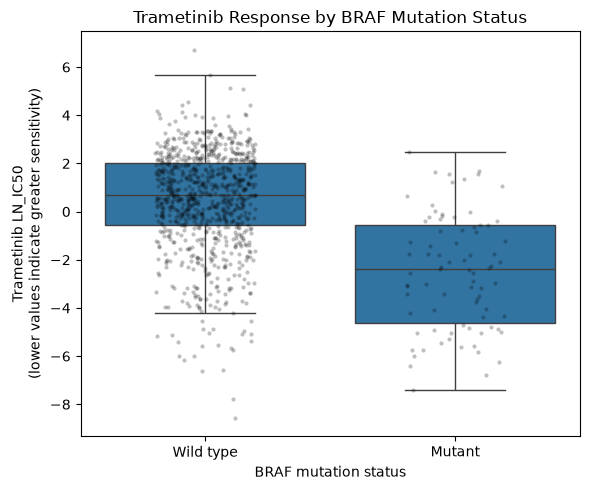

In [64]:
plt.figure(figsize=(6, 5))

sns.boxplot(
    data=trametinib_matched,
    x="BRAF_status",
    y="LN_IC50",
    order=["Wild type", "Mutant"],
    showfliers=False
)

sns.stripplot(
    data=trametinib_matched,
    x="BRAF_status",
    y="LN_IC50",
    order=["Wild type", "Mutant"],
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.2
)

plt.xlabel("BRAF mutation status")
plt.ylabel(
    "Trametinib LN_IC50\n"
    "(lower values indicate greater sensitivity)"
)

plt.title("Trametinib Response by BRAF Mutation Status")

plt.tight_layout()
plt.show()

In [65]:
braf_mutant_ln_ic50 = trametinib_matched.loc[
    trametinib_matched["BRAF_status"] == "Mutant",
    "LN_IC50"
]

braf_wildtype_ln_ic50 = trametinib_matched.loc[
    trametinib_matched["BRAF_status"] == "Wild type",
    "LN_IC50"
]

braf_u_statistic, braf_p_value = mannwhitneyu(
    braf_mutant_ln_ic50,
    braf_wildtype_ln_ic50,
    alternative="two-sided"
)

print(
    f"BRAF Mann–Whitney U statistic: "
    f"{braf_u_statistic:.0f}"
)

print(f"BRAF p-value: {braf_p_value:.3e}")

BRAF Mann–Whitney U statistic: 12267
BRAF p-value: 1.059e-22


BRAF-mutant cell lines demonstrated a lower median LN_IC50 than BRAF
wild-type cell lines, indicating greater average sensitivity to
Trametinib. The difference between the distributions was statistically
significant.

However, this analysis grouped all annotated BRAF mutations together
and did not distinguish activating variants such as BRAF V600 from
variants with different or uncertain functional consequences. BRAF
mutation status should therefore be interpreted as a broad genomic
feature rather than a direct measure of MAPK pathway activation.

## 4.10 Exploratory Analysis Summary

Exploratory analysis demonstrated substantial variation in Trametinib response across the 948 matched cancer cell lines, supporting the use of LN_IC50 as the continuous response variable for downstream machine learning models. The matched cohort represented a broad range of tumour types and contained recurrent alterations in several established cancer driver genes, including TP53, KRAS, BRAF, PTEN and PIK3CA.

Given the mechanism of action of Trametinib, particular attention was paid to alterations within the MAPK signalling pathway. MAPK pathway mutation burden showed a statistically significant negative association with Trametinib LN_IC50, indicating that cell lines with a greater number of mutated MAPK pathway genes tended to exhibit increased drug sensitivity. Analysis of individual driver genes demonstrated that both KRAS-mutant and BRAF-mutant cell lines exhibited significantly lower LN_IC50 values than their respective wild-type groups, although substantial variability remained within each group.

Collectively, these findings suggest that while MAPK pathway alterations contribute to Trametinib response, they do not fully explain the observed variation in drug sensitivity. Additional genomic alterations are therefore likely to influence response, supporting the use of multivariable machine learning models that incorporate the broader cancer driver mutation profile rather than relying solely on individual genes or pathway-level summaries.

# 5. Next Steps

The exploratory analyses presented in this notebook established a validated and biologically relevant dataset linking cancer driver mutations with experimentally measured Trametinib response.

The next stage of the project will transform the long-format mutation data into a machine-learning-ready feature matrix, engineer genomic predictor variables, and evaluate supervised machine learning models for predicting Trametinib sensitivity. Model performance will be assessed using standard regression metrics and feature importance analyses to identify the genomic alterations that contribute most strongly to drug response.